In [1]:
# import pandas as pd
import matplotlib.pyplot as plt
import skrf

In [2]:
xlzdDirectory = '../data/VNA_Measurements/rg316'
#rg316_100metres = skrf.Network('C:/Users/phdgc/OneDrive - University of Bristol/XLZD/VNA Measurements/rg316/rg316_100metres_librevna_two-1m-cables_1M_500M_1024pts.s1p.s2p')
rg316_100metres = skrf.Network( xlzdDirectory + '/rg316_100metres_librevna_two-1m-cables_1M_500M_1024pts.s1p.s2p')
rg316_specification = skrf.Network( xlzdDirectory + '/tasker_rg316_data.s1p')
rg400_specification = skrf.Network(xlzdDirectory + '/awc_rg400_data.s1p')
rg400_data_50metres = skrf.Network(xlzdDirectory + '/habia_rg400_100metres_librevna_two-1m-cables_1M_500M_1024pts.s1p.s2p')
rg400_data_100metres = rg400_data_50metres**rg400_data_50metres

In [3]:
rg316_100metres


2-Port Network: 'rg316_100metres_librevna_two-1m-cables_1M_500M_1024pts.s1p',  0.001-0.5 GHz, 1024 pts, z0=[50.+0.j 50.+0.j]

In [4]:
pdf_rg400_data_100metres = skrf.network_2_dataframe(rg400_data_100metres)
print(pdf_rg400_data_100metres)
pdf_rg400_data_100metres.dtypes
pdf_rg400_data_100metres.index
pdf_rg400_data_100metres.columns
pdf_rg400_data_100metres["s_db 21"]
pdf_rg400_data_100metres["s_db 21"] = pdf_rg400_data_100metres["s_db 21"]/4
print(pdf_rg400_data_100metres["s_db 21"])
narray_rg400_data_100metres = pdf_rg400_data_100metres.to_numpy()
print(narray_rg400_data_100metres)
print("index" , pdf_rg400_data_100metres.index)


                 s_db 11     s_db 21     s_db 12     s_db 22
0.000000e+00 -188.046096   -0.350957   -0.350957 -188.046096
1.000000e+06  -34.439449   -1.116040   -1.123254  -34.821882
1.487781e+06  -17.733079   -1.577748   -1.534198  -17.952843
1.975562e+06  -17.957120   -1.726075   -1.726382  -18.235197
2.463343e+06  -20.958853   -1.777296   -1.776984  -21.166440
...                  ...         ...         ...         ...
4.990244e+08  -36.674766  -32.460735  -32.473626  -40.950339
4.995122e+08  -36.737442  -32.478165  -32.485979  -40.251051
5.000000e+08  -36.814663  -32.497707  -32.510912  -39.299895
1.000000e+09  -36.962288  -50.753026  -50.753026  -39.447521
6.000000e+10 -116.989700 -233.979400 -233.979400 -116.989700

[1027 rows x 4 columns]
0.000000e+00    -0.087739
1.000000e+06    -0.279010
1.487781e+06    -0.394437
1.975562e+06    -0.431519
2.463343e+06    -0.444324
                  ...    
4.990244e+08    -8.115184
4.995122e+08    -8.119541
5.000000e+08    -8.124427
1.000000e

In [5]:
#print(rg400_data_100metres.s)
print(rg400_data_100metres.s_db)

[[[-188.04609628   -0.35095697]
  [  -0.35095697 -188.04609628]]

 [[ -34.4394487    -1.12325353]
  [  -1.1160402   -34.82188183]]

 [[ -17.73307928   -1.53419779]
  [  -1.57774785  -17.9528433 ]]

 ...

 [[ -36.81466261  -32.51091168]
  [ -32.49770731  -39.29989513]]

 [[ -36.96228815  -50.75302618]
  [ -50.75302618  -39.44752068]]

 [[-116.98970004 -233.97940009]
  [-233.97940009 -116.98970004]]]


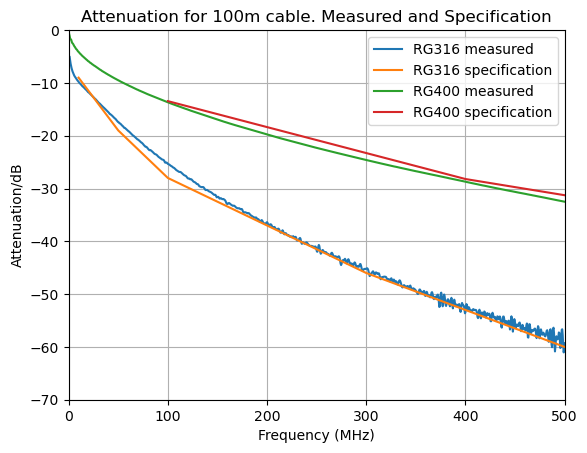

In [17]:
rg316_100metres_plt = rg316_100metres.plot_s_db(n=0,m=1, label="RG316 measured")
rg316_specification.plot_s_db(ax=rg316_100metres_plt, label= "RG316 specification")
rg400_data_100metres.plot_s_db(ax=rg316_100metres_plt,n=0,m=1, label="RG400 measured")
rg400_specification.plot_s_db(ax=rg316_100metres_plt,label="RG400 specification")

plt.ylabel("Attenuation/dB")
plt.title("Attenuation for 100m cable. Measured and Specification")
#rg316_100metres_plt.set_xlim([0,0.5])
plt.xlim([0,0.5e9])
plt.ylim([-70,0])
plt.grid()
plt.savefig("xlzd_od_rg316_rg400_100m_cable_attenuation.pdf", format="pdf") 

In [7]:
rg400_data_100metres

2-Port Network: 'habia_rg400_100metres_librevna_two-1m-cables_1M_500M_1024pts.s1p',  0.0-60.0 GHz, 1027 pts, z0=[50.+0.j 50.+0.j]